In [3]:
from pathlib import Path

from jax import config
import jax.numpy as np
config.update("jax_enable_x64", True)

from gwfast.lensing_utils import \
    compute_exact_lensed_angles, \
    get_lensed_parameter_sets, \
    einstein_radius
from gwfast.lensing_utils_alt import \
    compute_exact_lensed_angles_SourceFrame, \
    compute_lensed_angles_approx, \
    einstein_angle

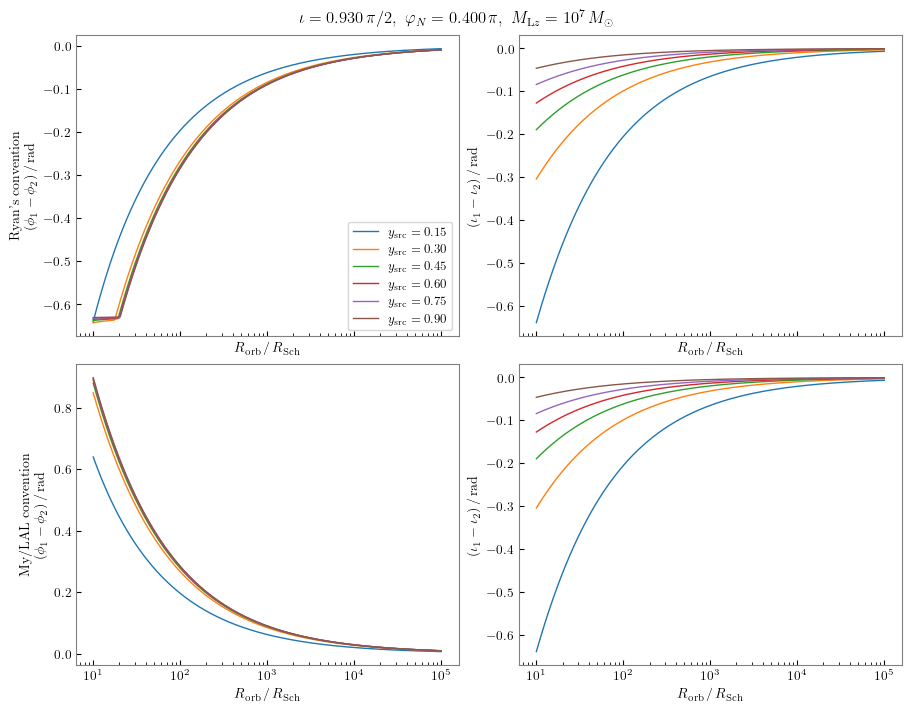

In [2]:
size = 500
iota_frac = 0.93
phi_N = np.pi * 0.4
r_orbits = np.geomspace(10, 100_000, size)
lensing_params = {
    'iota': np.full(size, iota_frac * np.pi / 2),
    'Phicoal': np.full(size, np.pi/2 - phi_N),
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}
lensing_params['psi'] = np.full(size, 0.0)
lensing_params['Mc'] = np.full(size, 1.0)

def regulate_phi_diff(phi_diff):
    mod2pi = np.mod(phi_diff, 2*np.pi)
    return np.where(mod2pi > np.pi, mod2pi - 2 * np.pi, mod2pi)

fig, Axes = plt.subplots(2, 2, figsize=(9, 7), 
                         sharex=True, constrained_layout=True)

axes = Axes.flatten()

for idx, y_src in enumerate(np.arange(0.15, 1, 0.15)):
    lensing_params['src_pos'] = np.full(size, y_src)
    lensed_params = compute_exact_lensed_angles(lensing_params)
    
    axes[0].plot(r_orbits, regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']),
                 c=f'C{idx}', label=fr'$y_{{\rm src}} = {y_src:>.2f}$')
    axes[1].plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], c=f'C{idx}')

    lensed_params = compute_exact_lensed_angles_SourceFrame(lensing_params)
    
    axes[2].plot(r_orbits, regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']),
                 c=f'C{idx}', label=fr'$y_{{\rm src}} = {y_src:>.2f}$')
    axes[3].plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], c=f'C{idx}')
    
axes[0].legend()
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel(r'$R_{\rm orb}\,/\,R_{\rm Sch}$')

# axes[1].set_ylim(-0.5e-15, 2e-15)
axes[0].set_ylabel("Ryan's convention\n" + r'$(\phi_1 - \phi_2)\,/\,{\rm rad}$')
axes[1].set_ylabel(r'$(\iota_1 - \iota_2)\,/\,{\rm rad}$')
axes[2].set_ylabel("My/LAL convention\n" + r'$(\phi_1 - \phi_2)\,/\,{\rm rad}$')
axes[3].set_ylabel(r'$(\iota_1 - \iota_2)\,/\,{\rm rad}$')
fig.suptitle(fr'$\iota = {iota_frac:.3f}\,\pi/2,\ \varphi_{{N}} = {phi_N/np.pi:.3f}\,\pi,\ M_{{{{\rm L}}z}} = 10^7\,M_\odot$')
fig.savefig('opening_angle_compare_plot.png', dpi=300)

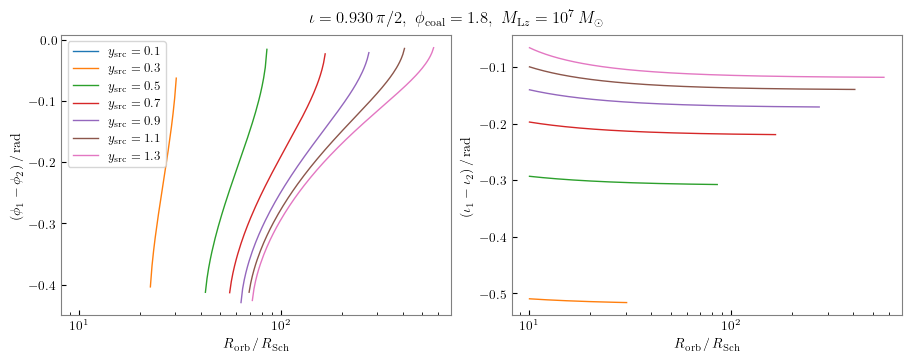

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), 
                         sharex=True, constrained_layout=True)
    
for idx, y_src in enumerate(range(1, 14, 2)):
    lensing_params['src_pos'] = np.full(size, y_src*0.1)
    # lensed_params = compute_exact_lensed_angles(lensing_params)

    approx_lensed = get_lensed_parameter_sets(lensing_params)
    d_iota = approx_lensed[0]['iota'] - approx_lensed[1]['iota'] 
    d_phi = approx_lensed[0]['Phicoal'] - approx_lensed[1]['Phicoal'] 
    
    axes[0].plot(r_orbits, regulate_phi_diff(d_phi), c=f'C{idx}', 
                 label=fr'$y_{{\rm src}} = {y_src*0.1:>.1f}$')
    axes[1].plot(r_orbits, d_iota, c=f'C{idx}')
    
axes[0].legend()
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel(r'$R_{\rm orb}\,/\,R_{\rm Sch}$')
    
axes[0].set_ylabel(r'$(\phi_1 - \phi_2)\,/\,{\rm rad}$')
axes[1].set_ylabel(r'$(\iota_1 - \iota_2)\,/\,{\rm rad}$')
fig.suptitle(fr'$\iota = {iota_frac:.3f}\,\pi/2,\ \phi_{{\rm coal}} = 1.8,\ M_{{{{\rm L}}z}} = 10^7\,M_\odot$')
fig.savefig('opening_angle_approx_plot.png', dpi=300)

In [4]:
# fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), 
#                          sharex=True, constrained_layout=True)

size = 400
r_orbits = np.geomspace(10, 100_000, size)
lensing_params = {
    'iota': np.full(size, np.pi/2 * 0.99),
    'Phicoal': np.full(size, 1.8),
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}

lensed_params = compute_exact_lensed_angles(lensing_params)

In [5]:
lensed_params

{'iota_p': Array([1.54658689, 1.54649213, 1.54639968, 1.54630949, 1.54622148,
        1.54613561, 1.54605182, 1.54597005, 1.54589024, 1.54581236,
        1.54573634, 1.54566214, 1.54558971, 1.54551901, 1.54544999,
        1.54538261, 1.54531684, 1.54525262, 1.54518992, 1.5451287 ,
        1.54506893, 1.54501056, 1.54495357, 1.54489793, 1.54484359,
        1.54479052, 1.5447387 , 1.54468809, 1.54463867, 1.54459041,
        1.54454327, 1.54449723, 1.54445227, 1.54440836, 1.54436547,
        1.54432358, 1.54428266, 1.5442427 , 1.54420366, 1.54416553,
        1.54412829, 1.54409191, 1.54405637, 1.54402166, 1.54398775,
        1.54395463, 1.54392227, 1.54389066, 1.54385979, 1.54382963,
        1.54380016, 1.54377138, 1.54374326, 1.54371579, 1.54368895,
        1.54366273, 1.54363712, 1.5436121 , 1.54358765, 1.54356377,
        1.54354044, 1.54351764, 1.54349537, 1.54347362, 1.54345236,
        1.54343159, 1.5434113 , 1.54339148, 1.54337211, 1.54335319,
        1.5433347 , 1.54331664, 1.5432

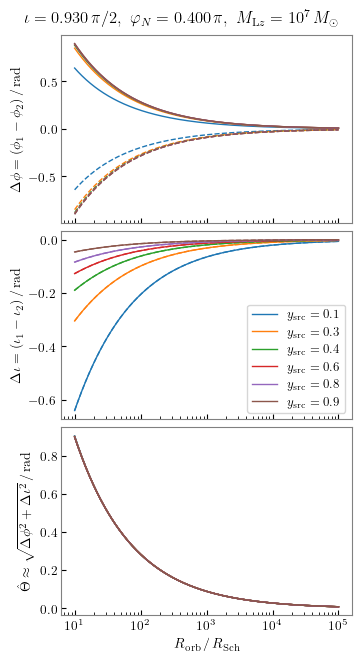

In [27]:
size = 500
iota_frac = 0.93
phi_N = np.pi * 0.4
r_orbits = np.geomspace(10, 100_000, size)
lensing_params = {
    'iota': np.full(size, iota_frac * np.pi / 2),
    'Phicoal': np.full(size, np.pi/2 - phi_N),
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}
lensing_params['psi'] = np.full(size, 0.0)
lensing_params['Mc'] = np.full(size, 1.0)

def regulate_phi_diff(phi_diff):
    mod2pi = np.mod(phi_diff, 2*np.pi)
    return np.where(mod2pi > np.pi, mod2pi - 2 * np.pi, mod2pi)

tilde_dls = r_orbits - 2
approx = np.arctan(
    np.sqrt(2 / tilde_dls) * 2 / (1 - 2 / tilde_dls))

fig, Axes = plt.subplots(3, 1, figsize=(3.5, 6.5), 
                         sharex=True, constrained_layout=True)

axes = Axes.flatten()

for idx, y_src in enumerate(np.arange(0.15, 1, 0.15)):
    lensing_params['src_pos'] = np.full(size, y_src)

    lensed_params = compute_exact_lensed_angles_SourceFrame(lensing_params)
    
    axes[0].plot(r_orbits, regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']),
                 c=f'C{idx}', label=fr'$y_{{\rm src}} = {y_src:>.1f}$')
    axes[1].plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], c=f'C{idx}',
                 label=fr'$y_{{\rm src}} = {y_src:>.1f}$')
    dphi = regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m'])
    diota = lensed_params['iota_p'] - lensed_params['iota_m']
    Theta = np.sqrt(dphi**2 + diota**2)
    axes[2].plot(r_orbits, Theta, c=f'C{idx}')

    lensing_params['src_pos'] = np.full(size, -y_src)

    lensed_params = compute_exact_lensed_angles_SourceFrame(lensing_params)
    
    axes[0].plot(r_orbits, regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']),
                 c=f'C{idx}', ls='--')
    axes[1].plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], c=f'C{idx}', ls='--')
    dphi = regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m'])
    diota = lensed_params['iota_p'] - lensed_params['iota_m']
    Theta = np.sqrt(dphi**2 + diota**2)
    axes[2].plot(r_orbits, Theta, c=f'C{idx}')

    
axes[1].legend()
for ax in axes:
    ax.set_xscale('log')
axes[2].set_xlabel(r'$R_{\rm orb}\,/\,R_{\rm Sch}$')

# axes[1].set_ylim(-0.5e-15, 2e-15)
axes[0].set_ylabel(r'$\Delta\phi = (\phi_1 - \phi_2)\,/\,{\rm rad}$')
axes[1].set_ylabel(r'$\Delta\iota = (\iota_1 - \iota_2)\,/\,{\rm rad}$')
axes[2].set_ylabel(r'$\hat\Theta \approx \sqrt{\Delta\phi^2 + \Delta\iota^2}\,/\,{\rm rad}$')
fig.suptitle(fr'$\iota = {iota_frac:.3f}\,\pi/2,\ \varphi_{{N}} = {phi_N/np.pi:.3f}\,\pi,\ M_{{{{\rm L}}z}} = 10^7\,M_\odot$')
fig.savefig('updated_opening_angle_plot.png', dpi=300)

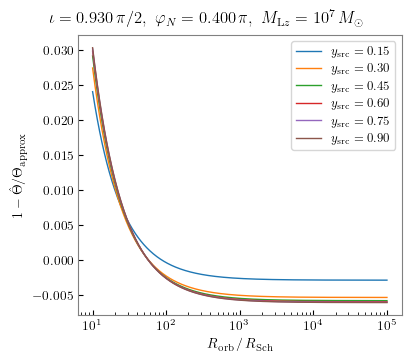

In [28]:
size = 500
iota_frac = 0.93
phi_N = np.pi * 0.4
r_orbits = np.geomspace(10, 100_000, size)
lensing_params = {
    'iota': np.full(size, iota_frac * np.pi / 2),
    'Phicoal': np.full(size, np.pi/2 - phi_N),
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}
lensing_params['psi'] = np.full(size, 0.0)
lensing_params['Mc'] = np.full(size, 1.0)

def regulate_phi_diff(phi_diff):
    mod2pi = np.mod(phi_diff, 2*np.pi)
    return np.where(mod2pi > np.pi, mod2pi - 2 * np.pi, mod2pi)

tilde_dls = r_orbits - 2
approx = np.arctan(
    np.sqrt(2 / tilde_dls) * 2 / (1 - 2 / tilde_dls))

fig, ax = plt.subplots(1, 1, figsize=(4, 3.5), 
                         sharex=True, constrained_layout=True)

for idx, y_src in enumerate(np.arange(0.15, 1, 0.15)):
    lensing_params['src_pos'] = np.full(size, y_src)

    lensed_params = compute_exact_lensed_angles_SourceFrame(lensing_params)
    dphi = regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m'])
    diota = lensed_params['iota_p'] - lensed_params['iota_m']
    Theta = np.sqrt(dphi**2 + diota**2)
    # axes[2].plot(r_orbits, Theta, c=f'C{idx}')
    
    ax.plot(r_orbits, 1 - Theta / approx,
                 c=f'C{idx}', label=fr'$y_{{\rm src}} = {y_src:>.2f}$')
    
ax.legend()

ax.set_xscale('log')
ax.set_xlabel(r'$R_{\rm orb}\,/\,R_{\rm Sch}$')

# axes[1].set_ylim(-0.5e-15, 2e-15)
ax.set_ylabel(r'$1 - \hat\Theta / \Theta_{\rm approx}$')
fig.suptitle(fr'$\iota = {iota_frac:.3f}\,\pi/2,\ \varphi_{{N}} = {phi_N/np.pi:.3f}\,\pi,\ M_{{{{\rm L}}z}} = 10^7\,M_\odot$')
fig.savefig('updated_opening_angle_ratio.png', dpi=300)

## Test Einstein radius, angular distance and all that

In [1]:
from jax import config
import jax.numpy as np
config.update("jax_enable_x64", True)

from gwfast.lensing_utils import \
    einstein_radius, \
    einstein_radius_angle

In [2]:
einstein_radius_angle?

Signature: einstein_radius_angle(lens_mass_source, D_L, D_LS)
Docstring:
Compute the Einstein radius (θ_E) from the given distances.

We assume D_S = D_L + D_LS, and we assume D_LS is sufficiently
small such that the (1 + z)^2 correction is unnecessary.

Making use of the distance hierarchsies, we write:
    θ_E^2 = 2 * (R_S / D_L) * [d_ls / (1 + d_ls)]
    where d_ls = D_LS / D_L

Parameters
----------
lens_mass_source: float / array-like
    The mass of the lens in the source frame, in solar masses.
D_L: float / array-like
    The luminosity distance between the lens and the observer, in Gpc.
D_LS: float / array-like
    The luminosity distance between the lens and the source, in R_Sch.

Returns
-------
theta_E: float / array-like
    The Einstein radius in radian.
File:      ~/src/AGN-gwfast/gwfast/lensing_utils.py
Type:      function

In [3]:
D_L_arr = np.linspace(0.1, 10, 100)  # Gpc
D_LS_arr = np.geomspace(2, 1000, 200)  # R_Sch
lens_mass_src = 1e5  # MSun

D_L_mesh, D_LS_mesh = np.meshgrid(D_L_arr, D_LS_arr, indexing='ij')

theta_E_Ryan = einstein_radius(lens_mass_src, D_L_mesh, D_LS_mesh)
theta_E = einstein_radius_angle(lens_mass_src, D_L_mesh, D_LS_mesh)

frac_diff = 1 - theta_E_Ryan / theta_E

In [4]:
D_L_mesh.shape

(100, 200)

Text(0.5, 0, '$D_{\\rm LS}\\,/\\,R_{\\rm Sch}$')

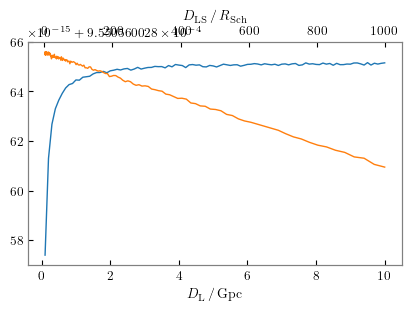

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True)
ax.plot(D_L_arr, np.mean(frac_diff, axis=1))
ax2 = ax.twiny()
ax2.plot(D_LS_arr, np.mean(frac_diff, axis=0), c='C1')
ax.set_xlabel(r'$D_{\rm L}\,/\,{\rm Gpc}$')
ax2.set_xlabel(r'$D_{\rm LS}\,/\,R_{\rm Sch}$')

Text(0.5, 0, '$D_{\\rm L}\\,/\\,{\\rm Gpc}$')

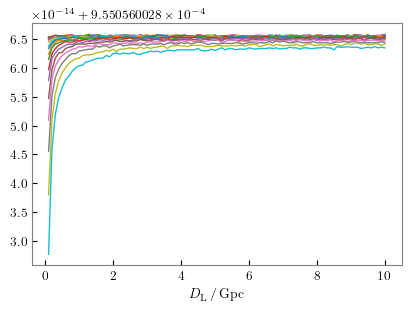

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True)
ax.plot(D_L_mesh[:, ::10], frac_diff[:, ::10])
ax.set_xlabel(r'$D_{\rm L}\,/\,{\rm Gpc}$')

In [7]:
theta_E_Ryan, theta_E

(Array([[1.99816654e-16, 2.02961196e-16, 2.06155225e-16, ...,
         4.33065933e-15, 4.39881151e-15, 4.46803621e-15],
        [1.04155904e-16, 1.05795020e-16, 1.07459931e-16, ...,
         2.25738811e-15, 2.29291294e-15, 2.32899682e-15],
        [7.22442981e-17, 7.33812166e-17, 7.45360269e-17, ...,
         1.56576260e-15, 1.59040322e-15, 1.61543162e-15],
        ...,
        [1.07443305e-17, 1.09134155e-17, 1.10851614e-17, ...,
         2.32863648e-16, 2.36528255e-16, 2.40250533e-16],
        [1.07370463e-17, 1.09060167e-17, 1.10776462e-17, ...,
         2.32705777e-16, 2.36367899e-16, 2.40087654e-16],
        [1.07301983e-17, 1.08990609e-17, 1.10705809e-17, ...,
         2.32557358e-16, 2.36217145e-16, 2.39934527e-16]], dtype=float64),
 Array([[2.00007672e-16, 2.03155221e-16, 2.06352303e-16, ...,
         4.33479930e-15, 4.40301664e-15, 4.47230752e-15],
        [1.04255474e-16, 1.05896157e-16, 1.07562659e-16, ...,
         2.25954610e-15, 2.29510489e-15, 2.33122327e-15],
        [7

## Check Phi_L calculations

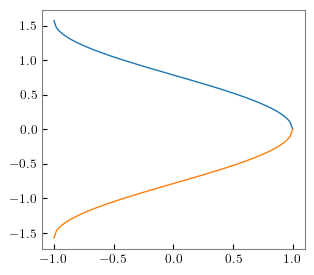

In [12]:
plt.plot(
    np.linspace(-1, 1, 100), np.arccos(np.linspace(-1, 1, 100))/2)
plt.plot(
    np.linspace(-1, 1, 100), -np.arccos(np.linspace(-1, 1, 100))/2)

Text(0.5, 1.0, "Paul's function")

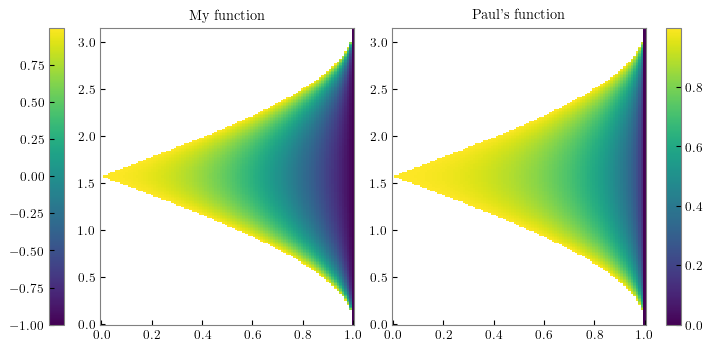

In [36]:
EPS = 1e-8
delta_arr = np.linspace(0, 1, 100)  # Gpc
iota_arr = np.linspace(EPS, np.pi-EPS, 200)  # R_Sch

delta_mesh, iota_mesh = np.meshgrid(delta_arr, iota_arr)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.4), constrained_layout=True)

ax = axes[0]
arg = 2 * (1 - delta_mesh**2) / np.sin(iota_mesh)**2 - 1
bound = np.abs(arg) <= 1
plot_arg = np.where(bound, arg, np.nan)
mesh = ax.pcolormesh(delta_mesh, iota_mesh, plot_arg)
fig.colorbar(mesh, ax=ax, location='left')
ax.set_title('My function')

ax = axes[1]
arg2 = np.sqrt(1 - delta_mesh**2) / np.sin(iota_mesh)
bound = np.abs(arg2) <= 1
plot_arg2 = np.where(bound, arg2, np.nan)
mesh = ax.pcolormesh(delta_mesh, iota_mesh, plot_arg2)
fig.colorbar(mesh, ax=ax, location='right')
ax.set_title("Paul's function")

In [39]:
def my_phi_L(delta, iota):
    arg = 2 * (1 - delta**2) / np.sin(iota)**2 - 1
    return np.arccos(arg) / 2

def phi_L(delta, iota):
    arg = np.sqrt(1 - delta**2) / np.sin(iota)
    return np.arccos(arg)

Text(0.5, 1.0, "Paul's function")

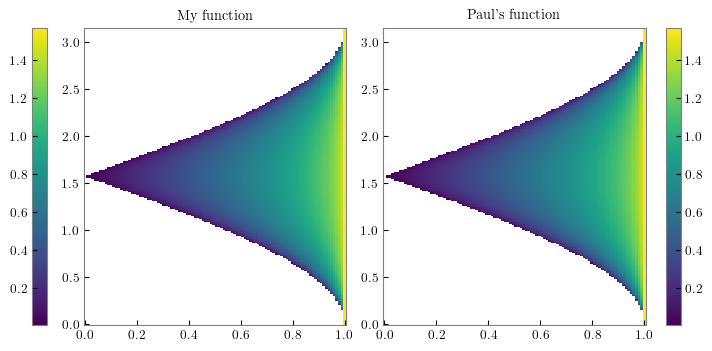

In [40]:
EPS = 1e-8
delta_arr = np.linspace(0, 1, 100)  # Gpc
iota_arr = np.linspace(EPS, np.pi-EPS, 200)  # R_Sch
delta_mesh, iota_mesh = np.meshgrid(delta_arr, iota_arr)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.4), constrained_layout=True)

ax = axes[0]
mesh = ax.pcolormesh(delta_mesh, iota_mesh, my_phi_L(delta_mesh, iota_mesh))
fig.colorbar(mesh, ax=ax, location='left')
ax.set_title('My function')

ax = axes[1]
mesh = ax.pcolormesh(delta_mesh, iota_mesh, phi_L(delta_mesh, iota_mesh))
fig.colorbar(mesh, ax=ax, location='right')
ax.set_title("Paul's function")

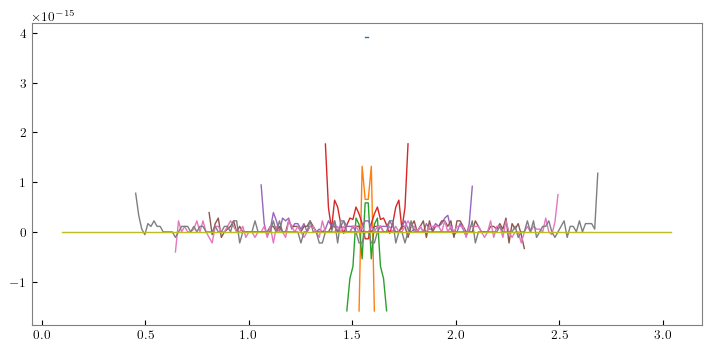

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3.4), constrained_layout=True)

iota_arr = np.linspace(0.1, np.pi-0.1, 200)
deltas = [0.01, 0.05, 0.1, 0.2, 0.5, 0.7, 0.8, 0.9, 1.0]

for delta in deltas:
    ax.plot(iota_arr, phi_L(delta, iota_arr) - my_phi_L(delta, iota_arr), label=fr'$\delta = {delta:.2f}$')

## Test approximations

Text(0.5, 0.98, '$\\iota = 0.930\\,\\pi/2,\\ \\varphi_{N} = 0.700\\,\\pi,\\ M_{{\\rm L}z} = 10^7\\,M_\\odot$')

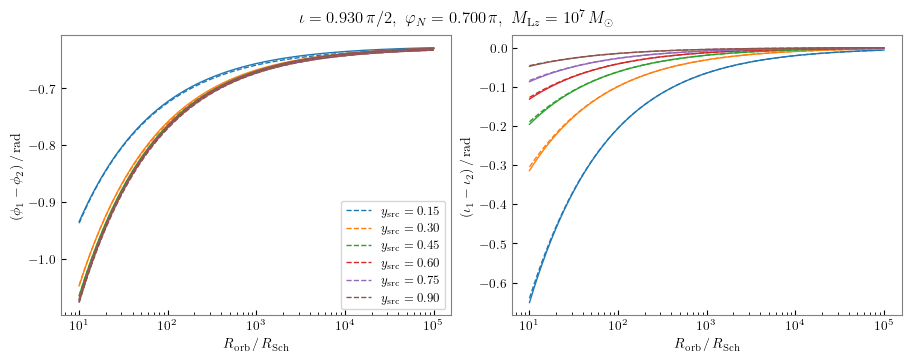

In [56]:
size = 500
iota_frac = 0.93
phi_N = np.pi * 0.7
r_orbits = np.geomspace(10, 100_000, size)
lensing_params = {
    'iota': np.full(size, iota_frac * np.pi / 2),
    'Phicoal': np.full(size, np.pi/2 - phi_N),
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}
lensing_params['psi'] = np.full(size, 0.0)
lensing_params['Mc'] = np.full(size, 1.0)

def regulate_phi_diff(phi_diff):
    mod2pi = np.mod(phi_diff, 2*np.pi)
    return np.where(mod2pi > np.pi, mod2pi - 2 * np.pi, mod2pi)

fig, Axes = plt.subplots(1, 2, figsize=(9, 3.5), 
                         sharex=True, constrained_layout=True)

axes = Axes.flatten()

for idx, y_src in enumerate(np.arange(0.15, 1, 0.15)):
    lensing_params['src_pos'] = np.full(size, y_src)
    lensed_params = compute_exact_lensed_angles_SourceFrame(lensing_params)
    
    # axes[0].plot(r_orbits, regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']),
    axes[0].plot(r_orbits, lensed_params['phase_m'],
                 c=f'C{idx}', label=fr'$y_{{\rm src}} = {y_src:>.2f}$', ls='--')
    axes[1].plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], c=f'C{idx}', ls='--')

    lensed_params = compute_lensed_angles_approx(lensing_params)
    
    # axes[0].plot(r_orbits, -regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']),
    axes[0].plot(r_orbits, -lensed_params['phase_m'] -np.pi/2 + 0.317,
                 c=f'C{idx}')
    axes[1].plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], c=f'C{idx}')

    # params_1, params_2 = get_lensed_parameter_sets(lensing_params)
    # axes[0].plot(r_orbits, -regulate_phi_diff(params_1['Phicoal'] - params_2['Phicoal']),
    #              c=f'C{idx}', ls='-.')
    # axes[1].plot(r_orbits, params_1['iota'] - params_2['iota'], c=f'C{idx}', ls='-.')
    
axes[0].legend()
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel(r'$R_{\rm orb}\,/\,R_{\rm Sch}$')

# axes[1].set_ylim(-0.5e-15, 2e-15)
axes[0].set_ylabel(r'$(\phi_1 - \phi_2)\,/\,{\rm rad}$')
axes[1].set_ylabel(r'$(\iota_1 - \iota_2)\,/\,{\rm rad}$')
fig.suptitle(fr'$\iota = {iota_frac:.3f}\,\pi/2,\ \varphi_{{N}} = {phi_N/np.pi:.3f}\,\pi,\ M_{{{{\rm L}}z}} = 10^7\,M_\odot$')
# fig.savefig('opening_angle_compare_approx_plot.png', dpi=300)

In [59]:
0.4 * np.pi / 2, -np.pi/2 + 0.317, 0.7* np.pi/2

(0.6283185307179586, -1.2537963267948966, 1.0995574287564276)

In [14]:
from jax import config, jit
import jax.numpy as np
config.update("jax_enable_x64", True)

from gwfast.lensing_utils import \
    compute_exact_lensed_angles, \
    get_lensed_parameter_sets, \
    einstein_radius
from gwfast.lensing_utils_alt import \
    compute_exact_lensed_angles_SourceFrame, \
    compute_lensed_angles_approx, \
    einstein_angle

Text(0.5, 0.98, '$\\iota = 1.040\\,\\pi/2,\\ \\varphi_{N} = 1.300\\,\\pi,\\ M_{{\\rm L}z} = 10^7\\,M_\\odot$')

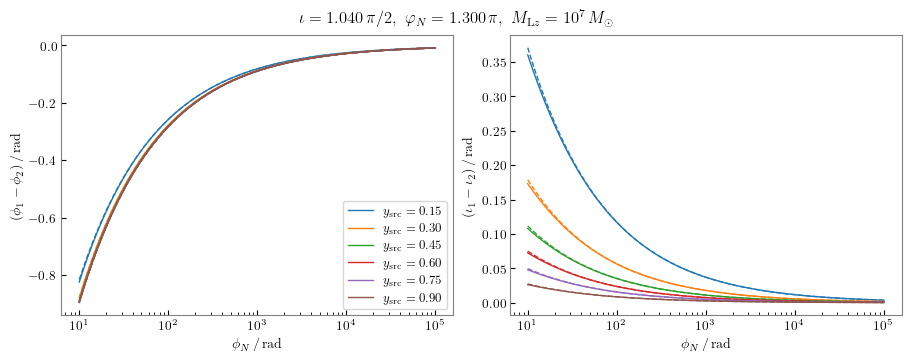

In [20]:
size = 500
iota_frac = 1.04
phi_N = np.pi * 1.3
r_orbits = np.geomspace(10, 100_000, size)
phi_Ns = np.linspace(0, 2*np.pi, size)
lensing_params = {
    'iota': np.full(size, iota_frac * np.pi / 2),
    'Phicoal': np.pi/2 - phi_N,
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}
lensing_params['psi'] = np.full(size, 0.0)
lensing_params['Mc'] = np.full(size, 1.0)

def regulate_phi_diff(phi_diff):
    mod2pi = np.mod(phi_diff, 2*np.pi)
    return np.where(mod2pi > np.pi, mod2pi - 2 * np.pi, mod2pi)

fig, Axes = plt.subplots(1, 2, figsize=(9, 3.5), 
                         sharex=True, constrained_layout=True)

axes = Axes.flatten()

for idx, y_src in enumerate(np.arange(0.15, 1, 0.15)):
    lensing_params['src_pos'] = np.full(size, y_src)
    lensed_params = jit(compute_exact_lensed_angles_SourceFrame)(lensing_params)
    
    axes[0].plot(r_orbits, regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']),
    # axes[0].plot(phi_Ns, np.pi/2 - lensed_params['phase_p'],
                 c=f'C{idx}', label=fr'$y_{{\rm src}} = {y_src:>.2f}$')
    axes[1].plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], c=f'C{idx}')
    # axes[0].plot(phi_Ns, np.pi/2 - lensed_params['phase_m'],
    #              c=f'C1', ls='--')
    # axes[1].plot(phi_Ns, lensed_params['iota_p'], c=f'C0', ls='--')
    # axes[1].plot(phi_Ns, lensed_params['iota_m'], c=f'C1', ls='--')

    lensed_params = jit(compute_lensed_angles_approx)(lensing_params)
    
    axes[0].plot(r_orbits, regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']),
    # axes[0].plot(phi_Ns, np.pi/2 - lensed_params['phase_p'],
                 c=f'C{idx}', ls='--')
    axes[1].plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], c=f'C{idx}', ls='--')    
    # axes[0].plot(phi_Ns, np.pi/2 - lensed_params['phase_m'], c=f'C1')
    # axes[1].plot(phi_Ns, lensed_params['iota_m'], c=f'C1')

    # params_1, params_2 = get_lensed_parameter_sets(lensing_params)
    # axes[0].plot(r_orbits, -regulate_phi_diff(params_1['Phicoal'] - params_2['Phicoal']),
    #              c=f'C{idx}', ls='-.')
    # axes[1].plot(r_orbits, params_1['iota'] - params_2['iota'], c=f'C{idx}', ls='-.')
    
axes[0].legend()
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel(r'$\phi_{N}\,/\,{\rm rad}$')

# axes[0].axhline(-np.pi/2, c='grey')
# axes[1].set_ylim(-0.5e-15, 2e-15)
axes[0].set_ylabel(r'$(\phi_1 - \phi_2)\,/\,{\rm rad}$')
axes[1].set_ylabel(r'$(\iota_1 - \iota_2)\,/\,{\rm rad}$')
fig.suptitle(fr'$\iota = {iota_frac:.3f}\,\pi/2,\ \varphi_{{N}} = {phi_N/np.pi:.3f}\,\pi,\ M_{{{{\rm L}}z}} = 10^7\,M_\odot$')
# fig.savefig('opening_angle_compare_approx_plot.png', dpi=300)

In [19]:
%timeit jit(compute_exact_lensed_angles_SourceFrame)(lensing_params)
%timeit jit(compute_lensed_angles_approx)(lensing_params)

829 μs ± 2.04 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
716 μs ± 2.41 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Test bit-shifting to get factors of pi

In [29]:
np.pi << 1 == np.pi/2

TypeError: unsupported operand type(s) for <<: 'float' and 'int'

In [35]:
bin(int(np.abs(np.pi).view(np.int64)))

'0b100000000001001001000011111101101010100010001000010110100011000'

In [37]:
bin(int(np.abs(np.pi*2).view(np.int64)))

'0b100000000011001001000011111101101010100010001000010110100011000'

In [38]:
bin(pow(2,64-11))

'0b100000000000000000000000000000000000000000000000000000'

In [42]:
np.abs(int(np.abs(np.pi*2).view(np.int64)) - pow(2,64-12)).view(np.float64) /  np.pi

Array(1., dtype=float64)

In [43]:
np.finfo(np.float64)

finfo(resolution=1e-15, min=-1.7976931348623157e+308, max=1.7976931348623157e+308, dtype=float64)

In [47]:
man, exp = np.frexp(np.pi)
np.ldexp(man, exp+2) == np.pi * 4

Array(True, dtype=bool)

In [48]:
np.pi << 52

TypeError: unsupported operand type(s) for <<: 'float' and 'int'

In [49]:
0.1 << 1

TypeError: unsupported operand type(s) for <<: 'float' and 'int'